<a href="https://colab.research.google.com/github/stefanogiagu/corso_AI_2026/blob/main/MetodiAI_2026_E11_hamiltonian_neural_networks_double_mass_spring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hamiltonian Neural Networks: Double Mass-Spring System

This notebook introduces Hamiltonian Neural Networks (HNNs) using a simple conservative mechanical system: two masses connected by springs, with the first mass attached to a wall.

The objective is to compare two ways of learning dynamics from simulated data:

1. **Baseline vector-field network**: directly learns
   $$
   (q_1, q_2, p_1, p_2, m_1, m_2, k_1, k_2) \mapsto (\dot q_1, \dot q_2, \dot p_1, \dot p_2).
   $$

2. **Hamiltonian Neural Network**: learns a scalar Hamiltonian
   $$
   H_\theta(q,p;m_1,m_2,k_1,k_2)
   $$
   and derives the vector field from Hamilton's equations:
   $$
   \dot q = \frac{\partial H_\theta}{\partial p},
   \qquad
   \dot p = -\frac{\partial H_\theta}{\partial q}.
   $$

The two models are trained on local vector-field targets and compared using multi-step rollout error and energy conservation.

## 1. Imports and configuration

In [ ]:
import os
from pathlib import Path
import math
import random

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
seed = 42
random.seed(seed)
torch.manual_seed(seed)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Data directory
DATA_DIR = Path("data_hnn_double_mass_spring")
DATA_DIR.mkdir(exist_ok=True)

TRAIN_FILE = DATA_DIR / "train.pt"
VAL_FILE = DATA_DIR / "val.pt"
TEST_FILE = DATA_DIR / "test.pt"

Device: cuda


## 2. Physical system

We use canonical Hamiltonian variables:

$$
x = (q_1, q_2, p_1, p_2).
$$

The system parameters are:

$$
\theta = (m_1, m_2, k_1, k_2).
$$

For a two-mass/two-spring chain attached to a wall, the Hamiltonian is:

$$
H(q,p;m,k)
=
\frac{p_1^2}{2m_1}
+
\frac{p_2^2}{2m_2}
+
\frac{1}{2} k_1 q_1^2
+
\frac{1}{2} k_2(q_2-q_1)^2.
$$

Hamilton's equations give:

$$
\dot q_1 = \frac{p_1}{m_1},
\qquad
\dot q_2 = \frac{p_2}{m_2},
$$

$$
\dot p_1 = -k_1 q_1 + k_2(q_2-q_1),
\qquad
\dot p_2 = -k_2(q_2-q_1).
$$

In [ ]:
def true_hamiltonian(x, params):
    """
    Compute the physical Hamiltonian of the double mass-spring system.

    Args:
        x:      tensor [..., 4] = [q1, q2, p1, p2]
        params: tensor [..., 4] = [m1, m2, k1, k2]

    Returns:
        H: tensor [...]
    """
    q1, q2, p1, p2 = x[..., 0], x[..., 1], x[..., 2], x[..., 3]
    m1, m2, k1, k2 = params[..., 0], params[..., 1], params[..., 2], params[..., 3]

    kinetic = 0.5 * p1**2 / m1 + 0.5 * p2**2 / m2
    potential = 0.5 * k1 * q1**2 + 0.5 * k2 * (q2 - q1)**2
    return kinetic + potential


def true_vector_field(x, params):
    """
    Analytic Hamiltonian vector field.

    Args:
        x:      tensor [..., 4] = [q1, q2, p1, p2]
        params: tensor [..., 4] = [m1, m2, k1, k2]

    Returns:
        dxdt: tensor [..., 4] = [dq1/dt, dq2/dt, dp1/dt, dp2/dt]
    """
    q1, q2, p1, p2 = x[..., 0], x[..., 1], x[..., 2], x[..., 3]
    m1, m2, k1, k2 = params[..., 0], params[..., 1], params[..., 2], params[..., 3]

    dq1 = p1 / m1
    dq2 = p2 / m2
    dp1 = -k1 * q1 + k2 * (q2 - q1)
    dp2 = -k2 * (q2 - q1)

    return torch.stack([dq1, dq2, dp1, dp2], dim=-1)

## 3. Numerical integration with RK4

We use fourth-order Runge-Kutta to generate accurate trajectories. The purpose here is not to teach numerical integration in detail, but to obtain reliable supervised training data.

**A simplectic alghoritm would be better, in any case we will check if the error in energy of the simulation is negligible**

In [ ]:
def rk4_step(f, x, params, dt):
    """One Runge-Kutta 4 step for a vector field f(x, params)."""
    k1 = f(x, params)
    k2 = f(x + 0.5 * dt * k1, params)
    k3 = f(x + 0.5 * dt * k2, params)
    k4 = f(x + dt * k3, params)
    return x + dt * (k1 + 2*k2 + 2*k3 + k4) / 6

## 4. Dataset generation

Each trajectory is generated by sampling:

$$
m_1,m_2 \sim U(0.5,2.0),
\qquad
k_1,k_2 \sim U(0.5,3.0),
$$

and initial state:

$$
q_1,q_2,p_1,p_2 \sim U(-1,1).
$$

The saved data contain flattened samples for vector-field training, and trajectory tensors for rollout evaluation.

Files are saved separately as:

- `train.pt`
- `val.pt`
- `test.pt`

If the files already exist, simulation is skipped.

In [ ]:
def sample_uniform(shape, low, high):
    return low + (high - low) * torch.rand(shape)


def simulate_trajectory(n_steps, dt):
    """
    Simulate one trajectory with randomly sampled physical parameters and initial state.

    Returns:
        states: tensor [n_steps + 1, 4]
        params: tensor [4]
        dx:     tensor [n_steps + 1, 4]
    """
    m1m2 = sample_uniform((2,), 0.5, 2.0)
    k1k2 = sample_uniform((2,), 0.5, 3.0)
    params = torch.cat([m1m2, k1k2], dim=0)

    x = sample_uniform((4,), -1.0, 1.0)

    states = [x]
    for _ in range(n_steps):
        x = rk4_step(true_vector_field, x.unsqueeze(0), params.unsqueeze(0), dt).squeeze(0)
        states.append(x)

    states = torch.stack(states, dim=0)
    params_expanded = params.unsqueeze(0).expand(states.shape[0], -1)
    dx = true_vector_field(states, params_expanded)

    return states, params, dx


def make_split(n_traj, n_steps, dt):
    """
    Generate one dataset split.

    The split contains both flattened samples and trajectory-level data.
    Flattened samples are used for supervised vector-field training.
    Trajectories are used for rollout evaluation and plotting.
    """
    trajectories = []
    trajectory_params = []
    trajectory_dx = []

    xs = []
    params_flat = []
    dxs = []
    x_nexts = []

    for _ in range(n_traj):
        states, params, dx = simulate_trajectory(n_steps=n_steps, dt=dt)

        trajectories.append(states)
        trajectory_params.append(params)
        trajectory_dx.append(dx)

        # Use samples 0..n_steps-1 for one-step pairs.
        xs.append(states[:-1])
        x_nexts.append(states[1:])
        dxs.append(dx[:-1])
        params_flat.append(params.unsqueeze(0).expand(n_steps, -1))

    data = {
        "x": torch.cat(xs, dim=0),
        "params": torch.cat(params_flat, dim=0),
        "dx": torch.cat(dxs, dim=0),
        "x_next": torch.cat(x_nexts, dim=0),
        "trajectories": torch.stack(trajectories, dim=0),        # [n_traj, n_steps+1, 4]
        "trajectory_params": torch.stack(trajectory_params, dim=0), # [n_traj, 4]
        "trajectory_dx": torch.stack(trajectory_dx, dim=0),      # [n_traj, n_steps+1, 4]
        "dt": dt,
        "n_steps": n_steps,
        "meta": {
            "system": "double_mass_spring_wall_chain",
            "state_order": ["q1", "q2", "p1", "p2"],
            "param_order": ["m1", "m2", "k1", "k2"],
            "hamiltonian": "p1^2/(2m1) + p2^2/(2m2) + 0.5*k1*q1^2 + 0.5*k2*(q2-q1)^2"
        }
    }
    return data


# Dataset size for one lab session.
# Increase these values for better final performance.
dt = 0.05
n_steps_per_traj = 200
n_train_traj = 2000
n_val_traj = 200
n_test_traj = 200

if TRAIN_FILE.exists() and VAL_FILE.exists() and TEST_FILE.exists():
    print("Dataset files already exist. Loading cached data.")
else:
    print("Generating datasets...")
    train_data = make_split(n_train_traj, n_steps_per_traj, dt)
    val_data = make_split(n_val_traj, n_steps_per_traj, dt)
    test_data = make_split(n_test_traj, n_steps_per_traj, dt)

    torch.save(train_data, TRAIN_FILE)
    torch.save(val_data, VAL_FILE)
    torch.save(test_data, TEST_FILE)
    print("Saved:", TRAIN_FILE, VAL_FILE, TEST_FILE)

train_data = torch.load(TRAIN_FILE, map_location="cpu")
val_data = torch.load(VAL_FILE, map_location="cpu")
test_data = torch.load(TEST_FILE, map_location="cpu")

print("Train samples:", train_data["x"].shape[0])
print("Validation samples:", val_data["x"].shape[0])
print("Test samples:", test_data["x"].shape[0])
print("Train trajectories:", train_data["trajectories"].shape)

Generating datasets...
Saved: data_hnn_double_mass_spring/train.pt data_hnn_double_mass_spring/val.pt data_hnn_double_mass_spring/test.pt
Train samples: 400000
Validation samples: 40000
Test samples: 40000
Train trajectories: torch.Size([2000, 201, 4])


## 5. Dataset sanity checks

Before training, plot one true trajectory and verify that the true physical energy is nearly conserved.

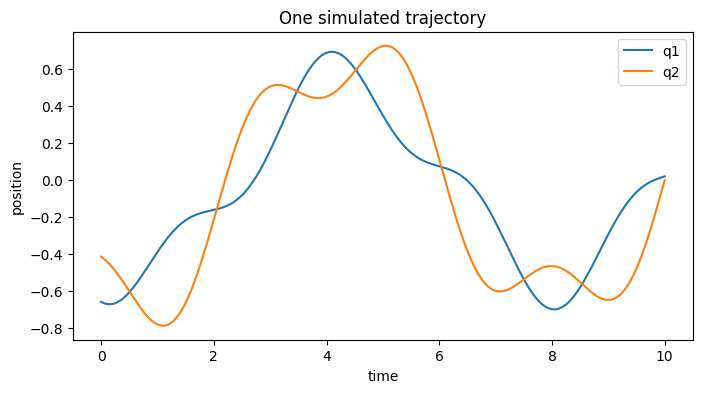

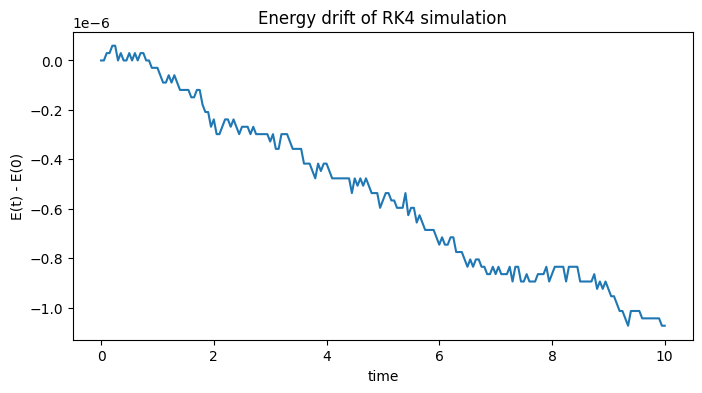

In [ ]:
def plot_true_trajectory(data, trajectory_index=0):
    traj = data["trajectories"][trajectory_index]
    params = data["trajectory_params"][trajectory_index]
    dt = data["dt"]
    t = torch.arange(traj.shape[0]) * dt

    energy = true_hamiltonian(traj, params.unsqueeze(0).expand(traj.shape[0], -1))

    plt.figure(figsize=(8, 4))
    plt.plot(t, traj[:, 0], label="q1")
    plt.plot(t, traj[:, 1], label="q2")
    plt.xlabel("time")
    plt.ylabel("position")
    plt.title("One simulated trajectory")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(t, energy - energy[0])
    plt.xlabel("time")
    plt.ylabel("E(t) - E(0)")
    plt.title("Energy drift of RK4 simulation")
    plt.show()

plot_true_trajectory(train_data, trajectory_index=0)

## 6. PyTorch dataset and dataloaders

In [ ]:
class VectorFieldDataset(Dataset):
    def __init__(self, data):
        self.x = data["x"].float()
        self.params = data["params"].float()
        self.dx = data["dx"].float()

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.params[idx], self.dx[idx]


batch_size = 2048

train_loader = DataLoader(VectorFieldDataset(train_data), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(VectorFieldDataset(val_data), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(VectorFieldDataset(test_data), batch_size=batch_size, shuffle=False)

## 7. Baseline vector-field network

The baseline directly predicts the vector field:

$$
(x,\theta) \mapsto \dot x.
$$

It is flexible, but it does not explicitly encode conservation of energy or Hamiltonian structure.

We use `GELU` as a smooth activation. Smooth activations are especially important for the HNN, because the vector field is obtained by differentiating the network output with respect to the input state. ReLU is usually avoided in this context.

In [ ]:
class BaselineVectorField(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=128, output_dim=4, activation=nn.GELU):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            activation(),
            nn.Linear(hidden_dim, hidden_dim),
            activation(),
            nn.Linear(hidden_dim, hidden_dim),
            activation(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x, params):
        """
        Direct vector-field model.

        Args:
            x:      [batch, 4] = [q1, q2, p1, p2]
            params: [batch, 4] = [m1, m2, k1, k2]

        Returns:
            dxdt:   [batch, 4] = [dq1/dt, dq2/dt, dp1/dt, dp2/dt]
        """
        inp = torch.cat([x, params], dim=-1)
        return self.net(inp)

## 8. Hamiltonian Neural Network

The HNN learns a scalar function:

$$
H_\phi(q_1,q_2,p_1,p_2;m_1,m_2,k_1,k_2).
$$

The physical parameters are inputs to the Hamiltonian network, but they are **not canonical variables**. Therefore, Hamilton's equations require gradients with respect to the state variables \((q,p)\), not with respect to \((m_1,m_2,k_1,k_2)\).

This distinction is explicit in the code: `torch.autograd.grad(..., inputs=x)` computes derivatives only with respect to `x`.

In [ ]:
class HamiltonianNN(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=128, activation=nn.GELU):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            activation(),
            nn.Linear(hidden_dim, hidden_dim),
            activation(),
            nn.Linear(hidden_dim, hidden_dim),
            activation(),
            nn.Linear(hidden_dim, 1),
        )

    def hamiltonian(self, x, params):
        """
        Neural Hamiltonian.

        Args:
            x:      [batch, 4] = [q1, q2, p1, p2]
            params: [batch, 4] = [m1, m2, k1, k2]

        Returns:
            H:      [batch, 1]

        The physical parameters condition the Hamiltonian, but Hamilton's
        equations differentiate only with respect to the canonical variables x.
        """
        inp = torch.cat([x, params], dim=-1)
        return self.net(inp)

    def forward(self, x, params):
        """
        Compute the Hamiltonian vector field.

        Hamilton's equations:
            dq/dt =  dH/dp
            dp/dt = -dH/dq

        Important teaching point:
            - We require gradients with respect to x = [q1, q2, p1, p2].
            - We do NOT require gradients with respect to params = [m1, m2, k1, k2].
            - params are conditioning variables, not canonical variables.
        """
        # Create a differentiable copy of the state.
        # This is the variable with respect to which Hamilton's equations are computed.
        with torch.enable_grad():
          x = x.detach().clone().requires_grad_(True)

          # The physical parameters influence H, but Hamilton's equations do not use dH/dparams.
          # Detaching params avoids unnecessary gradients with respect to the parameter inputs.
          # This does NOT prevent training the network weights.
          params = params.detach()

          H = self.hamiltonian(x, params)

          # Compute dH/dx only. Since inputs=x, no gradients are computed with respect to params.
          grad_H = torch.autograd.grad(
              outputs=H.sum(),
              inputs=x,
              create_graph=self.training
          )[0]

        dH_dq = grad_H[:, 0:2]
        dH_dp = grad_H[:, 2:4]

        dqdt = dH_dp
        dpdt = -dH_dq

        return torch.cat([dqdt, dpdt], dim=-1)

### Diagnostic: HNN shapes and gradient logic

This diagnostic emphasizes that the model receives both state and physical parameters, but Hamiltonian differentiation is performed only with respect to the canonical state.

In [ ]:
x_batch, params_batch, dx_batch = next(iter(train_loader))
x_batch = x_batch.to(device)
params_batch = params_batch.to(device)

_tmp_hnn = HamiltonianNN(hidden_dim=128, activation=nn.GELU).to(device)
dx_pred = _tmp_hnn(x_batch, params_batch)

print("Input state shape:       ", x_batch.shape)
print("Input parameter shape:   ", params_batch.shape)
print("Predicted dx/dt shape:   ", dx_pred.shape)
print("External x requires grad:", x_batch.requires_grad)
print("Params require grad:     ", params_batch.requires_grad)
print("Note: the HNN creates an internal differentiable copy of x for dH/dx.")

Input state shape:        torch.Size([2048, 4])
Input parameter shape:    torch.Size([2048, 4])
Predicted dx/dt shape:    torch.Size([2048, 4])
External x requires grad: False
Params require grad:      False
Note: the HNN creates an internal differentiable copy of x for dH/dx.


## 9. Training functions

Both models are trained on the same supervised vector-field objective:

$$
\mathcal{L}
=
\|\dot x_{\text{pred}} - \dot x_{\text{true}}\|_2^2.
$$

For simplicity, the evaluation function does not use `torch.no_grad()`, because HNN inference still needs autograd to compute \(\nabla_x H\).

In [ ]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    total_samples = 0

    for x, params, dx_true in loader:
        x = x.to(device)
        params = params.to(device)
        dx_true = dx_true.to(device)

        dx_pred = model(x, params)
        loss = torch.mean((dx_pred - dx_true) ** 2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        n = x.shape[0]
        total_loss += loss.item() * n
        total_samples += n

    return total_loss / total_samples


def evaluate_vector_field(model, loader):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    with torch.no_grad():
      for x, params, dx_true in loader:
          x = x.to(device)
          params = params.to(device)
          dx_true = dx_true.to(device)

          dx_pred = model(x, params)
          loss = torch.mean((dx_pred - dx_true) ** 2)

          n = x.shape[0]
          total_loss += loss.item() * n
          total_samples += n

    return total_loss / total_samples

## 10. Train baseline and HNN

For a short lab, 30--50 epochs are usually enough to see the qualitative behavior. Increase `n_epochs` for a cleaner final comparison.

In [ ]:
baseline = BaselineVectorField(hidden_dim=128, activation=nn.GELU).to(device)
hnn = HamiltonianNN(hidden_dim=128, activation=nn.GELU).to(device)

baseline_optimizer = torch.optim.Adam(baseline.parameters(), lr=5e-4)
hnn_optimizer = torch.optim.Adam(hnn.parameters(), lr=5e-4)

n_epochs = 50

baseline_history = {"train_loss": [], "val_loss": []}
hnn_history = {"train_loss": [], "val_loss": []}

for epoch in range(1, n_epochs + 1):
    baseline_train_loss = train_one_epoch(baseline, train_loader, baseline_optimizer)
    baseline_val_loss = evaluate_vector_field(baseline, val_loader)

    hnn_train_loss = train_one_epoch(hnn, train_loader, hnn_optimizer)
    hnn_val_loss = evaluate_vector_field(hnn, val_loader)

    baseline_history["train_loss"].append(baseline_train_loss)
    baseline_history["val_loss"].append(baseline_val_loss)
    hnn_history["train_loss"].append(hnn_train_loss)
    hnn_history["val_loss"].append(hnn_val_loss)

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Baseline train {baseline_train_loss:.6e}, val {baseline_val_loss:.6e} | "
            f"HNN train {hnn_train_loss:.6e}, val {hnn_val_loss:.6e}"
        )

Epoch 001 | Baseline train 2.952249e-01, val 3.168740e-02 | HNN train 3.659710e-01, val 4.960136e-02
Epoch 005 | Baseline train 1.586449e-03, val 1.640334e-03 | HNN train 2.661236e-03, val 2.846321e-03
Epoch 010 | Baseline train 6.457491e-04, val 6.555445e-04 | HNN train 7.698684e-04, val 8.564338e-04
Epoch 015 | Baseline train 4.066067e-04, val 4.265606e-04 | HNN train 4.137401e-04, val 4.067148e-04
Epoch 020 | Baseline train 2.881241e-04, val 2.657179e-04 | HNN train 3.013845e-04, val 2.691518e-04
Epoch 025 | Baseline train 1.940918e-04, val 2.639666e-04 | HNN train 2.177416e-04, val 1.945076e-04
Epoch 030 | Baseline train 1.495670e-04, val 1.967546e-04 | HNN train 2.004345e-04, val 1.986292e-04
Epoch 035 | Baseline train 1.403377e-04, val 9.800420e-05 | HNN train 1.372418e-04, val 1.514968e-04
Epoch 040 | Baseline train 1.325340e-04, val 9.196286e-05 | HNN train 1.126261e-04, val 1.267512e-04
Epoch 045 | Baseline train 1.232175e-04, val 7.829118e-05 | HNN train 1.204026e-04, val 1.6

## 11. Training curves

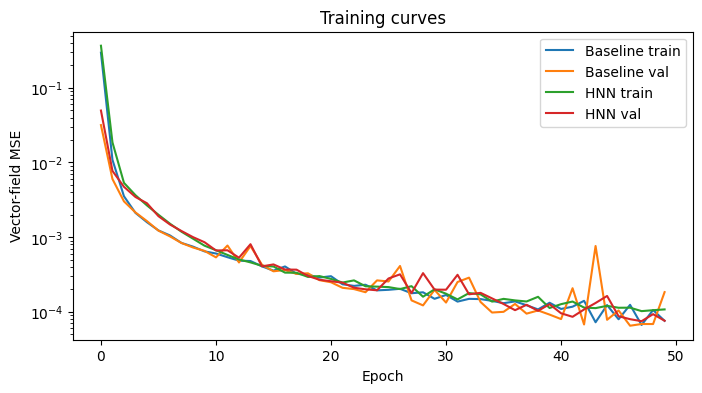

Baseline test vector-field MSE: 1.776657e-04
HNN test vector-field MSE:      6.889771e-05


In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(baseline_history["train_loss"], label="Baseline train")
plt.plot(baseline_history["val_loss"], label="Baseline val")
plt.plot(hnn_history["train_loss"], label="HNN train")
plt.plot(hnn_history["val_loss"], label="HNN val")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Vector-field MSE")
plt.title("Training curves")
plt.legend()
plt.show()

baseline_test_mse = evaluate_vector_field(baseline, test_loader)
hnn_test_mse = evaluate_vector_field(hnn, test_loader)

print(f"Baseline test vector-field MSE: {baseline_test_mse:.6e}")
print(f"HNN test vector-field MSE:      {hnn_test_mse:.6e}")

## 12. Rollouts from learned vector fields

Both models define vector fields, so both can be integrated using the same RK4 method.

Do not wrap HNN rollout in `torch.no_grad()`: HNN inference requires autograd to compute \(\nabla_x H\).

In [ ]:
def rk4_step_model(model, x, params, dt):
    k1 = model(x, params)
    k2 = model(x + 0.5 * dt * k1, params)
    k3 = model(x + 0.5 * dt * k2, params)
    k4 = model(x + dt * k3, params)
    return x + dt * (k1 + 2*k2 + 2*k3 + k4) / 6


def rollout_model(model, x0, params, dt, n_steps):
    """
    Roll out a learned vector field.

    Args:
        model: learned vector-field model
        x0: tensor [4]
        params: tensor [4]
        dt: time step
        n_steps: number of integration steps

    Returns:
        trajectory: tensor [n_steps + 1, 4]
    """
    model.eval()

    x = x0.unsqueeze(0).to(device)
    params = params.unsqueeze(0).to(device)
    with torch.no_grad():
      trajectory = [x.squeeze(0).detach().cpu()]

      for _ in range(n_steps):
          x = rk4_step_model(model, x, params, dt)
          trajectory.append(x.squeeze(0).detach().cpu())

    return torch.stack(trajectory, dim=0)


def rollout_true(x0, params, dt, n_steps):
    x = x0.unsqueeze(0)
    params = params.unsqueeze(0)

    trajectory = [x.squeeze(0)]

    for _ in range(n_steps):
        x = rk4_step(true_vector_field, x, params, dt)
        trajectory.append(x.squeeze(0))

    return torch.stack(trajectory, dim=0)


def rollout_error(pred_traj, true_traj):
    return torch.linalg.norm(pred_traj - true_traj, dim=-1)


def energy_drift(traj, params):
    params_expanded = params.unsqueeze(0).expand(traj.shape[0], -1)
    energies = true_hamiltonian(traj, params_expanded)
    drift = energies - energies[0]
    return energies, drift

## 13. Single trajectory comparison

In [ ]:
dt = test_data["dt"]
n_rollout_steps = 1000
trajectory_index = 0

x0 = test_data["trajectories"][trajectory_index, 0].float()
params = test_data["trajectory_params"][trajectory_index].float()

true_traj = rollout_true(x0, params, dt, n_rollout_steps)
baseline_traj = rollout_model(baseline, x0, params, dt, n_rollout_steps)
hnn_traj = rollout_model(hnn, x0, params, dt, n_rollout_steps)

t = torch.arange(n_rollout_steps + 1) * dt

baseline_err = rollout_error(baseline_traj, true_traj)
hnn_err = rollout_error(hnn_traj, true_traj)

true_energy, true_drift = energy_drift(true_traj, params)
baseline_energy, baseline_drift = energy_drift(baseline_traj, params)
hnn_energy, hnn_drift = energy_drift(hnn_traj, params)

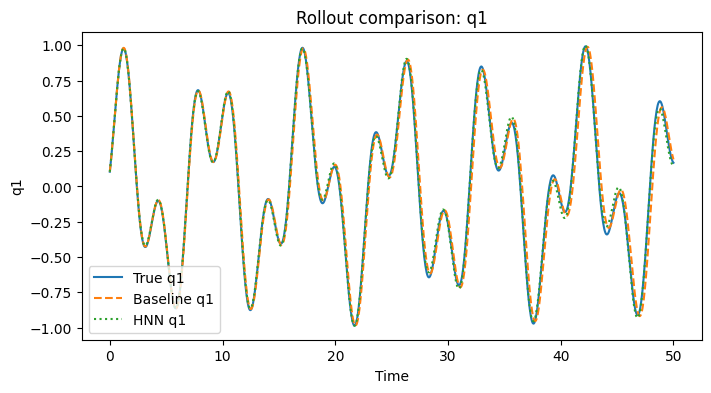

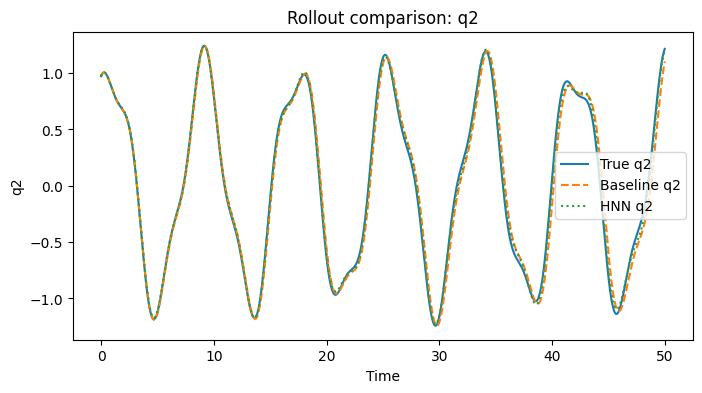

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(t, true_traj[:, 0], label="True q1")
plt.plot(t, baseline_traj[:, 0], "--", label="Baseline q1")
plt.plot(t, hnn_traj[:, 0], ":", label="HNN q1")
plt.xlabel("Time")
plt.ylabel("q1")
plt.title("Rollout comparison: q1")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t, true_traj[:, 1], label="True q2")
plt.plot(t, baseline_traj[:, 1], "--", label="Baseline q2")
plt.plot(t, hnn_traj[:, 1], ":", label="HNN q2")
plt.xlabel("Time")
plt.ylabel("q2")
plt.title("Rollout comparison: q2")
plt.legend()
plt.show()

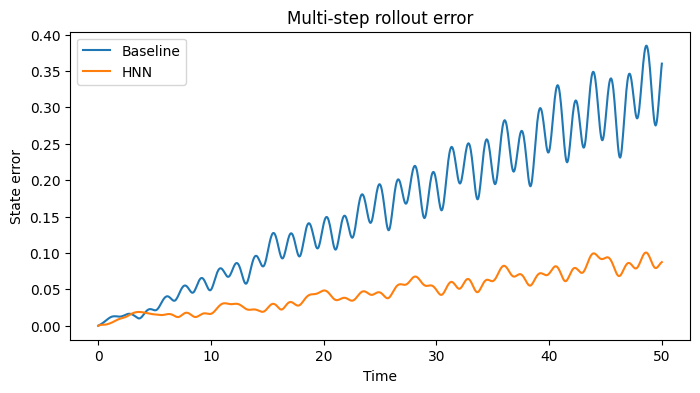

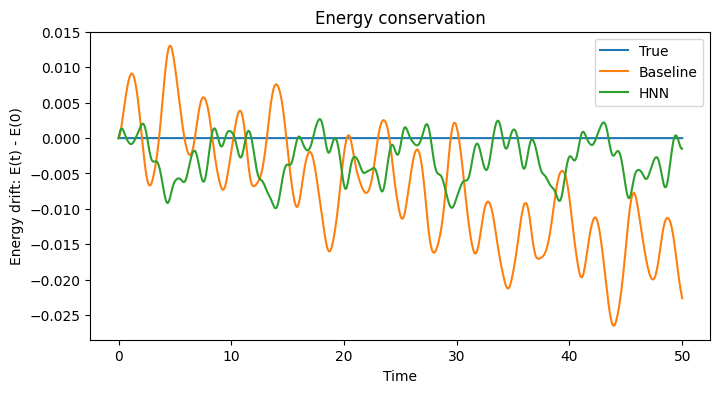

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(t, baseline_err, label="Baseline")
plt.plot(t, hnn_err, label="HNN")
plt.xlabel("Time")
plt.ylabel("State error")
plt.title("Multi-step rollout error")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t, true_drift, label="True")
plt.plot(t, baseline_drift, label="Baseline")
plt.plot(t, hnn_drift, label="HNN")
plt.xlabel("Time")
#plt.yscale("log")
plt.ylabel("Energy drift: E(t) - E(0)")
plt.title("Energy conservation")
plt.legend()
plt.show()

## 14. Test-set rollout evaluation

A single trajectory can be misleading. We now evaluate multiple test rollouts.

Metrics:

- mean rollout error over time;
- final rollout error;
- maximum absolute energy drift.

In [ ]:
def evaluate_rollouts(model, test_data, dt, n_steps=500, n_rollouts=50):
    model.eval()

    all_final_errors = []
    all_mean_errors = []
    all_energy_drifts = []

    n_available = test_data["trajectories"].shape[0]
    indices = torch.randperm(n_available)[:n_rollouts]

    for idx in indices:
        x0 = test_data["trajectories"][idx, 0].float()
        params = test_data["trajectory_params"][idx].float()

        true_traj = rollout_true(x0, params, dt, n_steps)
        pred_traj = rollout_model(model, x0, params, dt, n_steps)

        errors = rollout_error(pred_traj, true_traj)
        _, drift = energy_drift(pred_traj, params)

        all_final_errors.append(errors[-1].item())
        all_mean_errors.append(errors.mean().item())
        all_energy_drifts.append(drift.abs().max().item())

    return {
        "mean_rollout_error": torch.tensor(all_mean_errors).mean().item(),
        "final_rollout_error": torch.tensor(all_final_errors).mean().item(),
        "max_abs_energy_drift": torch.tensor(all_energy_drifts).mean().item(),
    }


baseline_rollout_results = evaluate_rollouts(
    baseline,
    test_data,
    dt,
    n_steps=200,
    n_rollouts=50
)

hnn_rollout_results = evaluate_rollouts(
    hnn,
    test_data,
    dt,
    n_steps=200,
    n_rollouts=50
)

results_df = pd.DataFrame([
    {"model": "Baseline", **baseline_rollout_results},
    {"model": "HNN", **hnn_rollout_results},
])

results_df

,model,mean_rollout_error,final_rollout_error,max_abs_energy_drift
0,Baseline,0.030837,0.051943,0.03840
1,HNN,0.032388,0.061718,0.01461


## 15. Discussion

The baseline and HNN are trained on the same local vector-field targets. The key difference is structural:

- the baseline predicts \(\dot x\) directly;
- the HNN predicts a scalar energy function and obtains \(\dot x\) through Hamilton's equations.

Do not expect the HNN to always have lower short-term state error. A sufficiently expressive baseline can fit the local vector field very well. The HNN's advantage is its inductive bias: the learned dynamics are constrained to be Hamiltonian.

The most important comparison is therefore not only vector-field MSE, but also long-term rollout behavior and energy drift.

Important implementation note: the physical parameters \((m_1,m_2,k_1,k_2)\) are inputs to the HNN because they determine the Hamiltonian. However, they are not canonical variables, so Hamilton's equations differentiate only with respect to \((q_1,q_2,p_1,p_2)\).

##16. Your Turn! (Lab Exercises)
Now it is your turn to modify the architectures and loss functions to see how different levels of physical inductive bias affect performance.

### Exercise 1: Physics-Informed Baseline (PINN approach)

Instead of forcing a rigid structural bias like the HNN, we can gently guide the standard baseline network by adding a soft thermodynamic constraint to its loss function.

**Task:Modify the training loop for the BaselineVectorField model to include a regularization term that penalizes deviations from energy conservation.**

 Your new loss function should look like:

 $$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{MSE}} + \lambda \mathcal{L}_{\text{energy}}$$

 where $\mathcal{L}_{\text{energy}}$ penalizes the predicted change in total energy over a local step, and $\lambda$ is a small weighting hyperparameter (e.g., $\lambda = 0.01$ or $0.1$).

 **Hint:** -->

 For a given batch state $x_t$, the baseline predicts $\dot{x}_t$. You can use a first-order Euler approximation (or RK4) to estimate the next state: $x_{t+1}^{\text{pred}} = x_t + \Delta t \cdot \dot{x}_t$.

 Compute the physical energy at the current state $E(x_t)$ and at the predicted next state $E(x_{t+1}^{\text{pred}})$ using the true_hamiltonian function.

 Since energy must be conserved, minimize the Mean Squared Error between $E(x_t)$ and $E(x_{t+1}^{\text{pred}})$.

 ### Exercise 2: Semi-Implicit HNN (Residual Potential Learning)

 In many real-world systems, we already know the exact mathematical form of the kinetic energy ($T = \frac{p^2}{2m}$) because mass is easy to measure. The real mystery is usually the complex potential energy field ($V(q)$).

 **Task:Modify the HamiltonianNN class so that the neural network only learns the potential energy**

  $$V_\phi(q, p; \theta)$$.
  
  The total Hamiltonian should be computed explicitly as:
  
  $$H(q,p) = T_{\text{known}}(p) + V_\phi(q, p; \theta)$$
  
  Where $T_{\text{known}}(p) = \frac{p_1^2}{2m_1} + \frac{p_2^2}{2m_2}$.Train this modified network and compare its convergence speed and rollout accuracy against the original HNN that had to learn the kinetic energy from scratch.
  
  **Hint:** --> Inside your new model's hamiltonian(self, x, params) method, manually parse out p1, p2, m1, m2 from the inputs. Calculate the analytical kinetic energy tensor explicitly.
  
  Then, let self.net(inp) run normally to output a scalar representing the rest of the Hamiltonian ($V$).
  
  Return the mathematical sum of the analytical kinetic energy and the neural network's output.
  
  PyTorch's Autograd will naturally handle the gradients for both parts seamlessly!
  


# Why this stuff is important
  - **soft constraints** is easy to code but highly sensitive to the hyperparameter $\lambda$. If $\lambda$ is too small, it ignores physics; if it's too large, it stops learning the vector field.
  
  - **residual learning** converges much faster and with a lower final validation error than the standard HNN, because it doesn't have to waste parameter capacity re-learning how squaring momentum works.

In [ ]:
# Why this stuff